In [2]:
import sqlite3
import pandas as pd
import os

In [3]:
# Define the path to the data folder and the database file
data_path = 'data'
db_path = 'olist.db'

# Create a connection to the SQLite database
# If the file doesn't exist, it will be created
conn = sqlite3.connect(db_path)

In [4]:
# Get a list of all CSV files in the data directory
csv_files = [f for f in os.listdir(data_path) if f.endswith('.csv')]

# Loop through each CSV file
for file in csv_files:
    # Construct the full file path
    file_path = os.path.join(data_path, file)
    
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)
    
    # Create a clean table name by removing the '.csv' and '_dataset' parts
    table_name = file.replace('.csv', '').replace('_dataset', '')
    
    # Write the DataFrame to the SQLite database
    # 'if_exists='replace'' means if the table is already there, it will be overwritten
    # This is useful for re-running the script
    df.to_sql(table_name, conn, if_exists='replace', index=False)
    
    print(f"Table '{table_name}' created successfully.")

print("\nAll CSV files have been imported into the database.")

Table 'olist_customers' created successfully.
Table 'olist_geolocation' created successfully.
Table 'olist_orders' created successfully.
Table 'olist_order_items' created successfully.
Table 'olist_order_payments' created successfully.
Table 'olist_order_reviews' created successfully.
Table 'olist_products' created successfully.
Table 'olist_sellers' created successfully.
Table 'product_category_name_translation' created successfully.

All CSV files have been imported into the database.


In [5]:
# Create a cursor object to execute SQL queries
cursor = conn.cursor()

# Query to get the list of all tables in the database
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")

# Fetch all the results
tables = cursor.fetchall()

print("\nTables in the database:")
for table in tables:
    print(table[0])

# Close the connection
conn.close()


Tables in the database:
olist_customers
olist_geolocation
olist_orders
olist_order_items
olist_order_payments
olist_order_reviews
olist_products
olist_sellers
product_category_name_translation


In [6]:
import sqlite3
import pandas as pd

# Define the path to your database
db_path = 'olist.db'

# Create a connection to the SQLite database
conn = sqlite3.connect(db_path)

In [7]:
# Create a cursor object to execute SQL queries
cursor = conn.cursor()

# Query to get the list of all tables
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")

# Fetch and print the results
tables = cursor.fetchall()
print("Tables available in the database:")
for table in tables:
    print(f"- {table[0]}")

Tables available in the database:
- olist_customers
- olist_geolocation
- olist_orders
- olist_order_items
- olist_order_payments
- olist_order_reviews
- olist_products
- olist_sellers
- product_category_name_translation


In [8]:
# Query to inspect the structure of the 'olist_orders' table
query = "PRAGMA table_info(olist_orders);"
pd.read_sql_query(query, conn)

,cid,name,type,notnull,dflt_value,pk
0,0,order_id,TEXT,0,None,0
1,1,customer_id,TEXT,0,None,0
2,2,order_status,TEXT,0,None,0
3,3,order_purchase_timestamp,TEXT,0,None,0
4,4,order_approved_at,TEXT,0,None,0
5,5,order_delivered_carrier_date,TEXT,0,None,0
6,6,order_delivered_customer_date,TEXT,0,None,0
7,7,order_estimated_delivery_date,TEXT,0,None,0


In [9]:
# Query to select the first 5 rows from the 'olist_orders' table
query = "SELECT * FROM olist_orders LIMIT 5;"
pd.read_sql_query(query, conn)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [10]:
# Inspect the structure of the 'olist_customers' table
query_structure = "PRAGMA table_info(olist_customers);"
print("Structure of olist_customers:")
display(pd.read_sql_query(query_structure, conn))

# Look at the first 5 rows of the 'olist_customers' table
print("\nFirst 5 rows of olist_customers:")
query_data = "SELECT * FROM olist_customers LIMIT 5;"
display(pd.read_sql_query(query_data, conn))

Structure of olist_customers:


,cid,name,type,notnull,dflt_value,pk
0,0,customer_id,TEXT,0,None,0
1,1,customer_unique_id,TEXT,0,None,0
2,2,customer_zip_code_prefix,INTEGER,0,None,0
3,3,customer_city,TEXT,0,None,0
4,4,customer_state,TEXT,0,None,0



First 5 rows of olist_customers:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [11]:
# Inspect the structure of the 'olist_order_items' table
query_structure = "PRAGMA table_info(olist_order_items);"
print("Structure of olist_order_items:")
display(pd.read_sql_query(query_structure, conn))

# Look at the first 5 rows of the 'olist_order_items' table
print("\nFirst 5 rows of olist_order_items:")
query_data = "SELECT * FROM olist_order_items LIMIT 5;"
display(pd.read_sql_query(query_data, conn))

Structure of olist_order_items:


,cid,name,type,notnull,dflt_value,pk
0,0,order_id,TEXT,0,None,0
1,1,order_item_id,INTEGER,0,None,0
2,2,product_id,TEXT,0,None,0
3,3,seller_id,TEXT,0,None,0
4,4,shipping_limit_date,TEXT,0,None,0
5,5,price,REAL,0,None,0
6,6,freight_value,REAL,0,None,0



First 5 rows of olist_order_items:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [12]:
query = """
SELECT
    o.order_id,
    o.order_status,
    c.customer_unique_id,
    c.customer_city,
    c.customer_state
FROM
    olist_orders o
LEFT JOIN
    olist_customers c ON o.customer_id = c.customer_id
LIMIT 5;
"""

pd.read_sql_query(query, conn)

,order_id,order_status,customer_unique_id,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,af07308b275d755c9edb36a90c618231,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP


In [13]:
query = """
SELECT
    o.order_id,
    o.order_status,
    c.customer_unique_id,
    p.payment_value,
    p.payment_type
FROM
    olist_orders o
LEFT JOIN
    olist_customers c ON o.customer_id = c.customer_id
LEFT JOIN
    olist_order_payments p ON o.order_id = p.order_id
LIMIT 5;
"""

pd.read_sql_query(query, conn)

,order_id,order_status,customer_unique_id,payment_value,payment_type
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,7c396fd4830fd04220f754e42b4e5bff,18.12,credit_card
1,e481f51cbdc54678b7cc49136f2d6af7,delivered,7c396fd4830fd04220f754e42b4e5bff,2.00,voucher
2,e481f51cbdc54678b7cc49136f2d6af7,delivered,7c396fd4830fd04220f754e42b4e5bff,18.59,voucher
3,53cdb2fc8bc7dce0b6741e2150273451,delivered,af07308b275d755c9edb36a90c618231,141.46,boleto
4,47770eb9100c2d0c44946d9cf07ec65d,delivered,3a653a41f6f9fc3d2a113cf8398680e8,179.12,credit_card


In [14]:
query = """
SELECT
    o.order_id,
    o.order_purchase_timestamp,
    o.order_delivered_customer_date,
    o.order_estimated_delivery_date,
    c.customer_unique_id,
    c.customer_city,
    c.customer_state,
    p.payment_value,
    oi.product_id,
    pr.product_category_name,
    pr.product_weight_g,
    pr.product_length_cm,
    pr.product_width_cm,
    pr.product_height_cm
FROM
    olist_orders o
LEFT JOIN
    olist_customers c ON o.customer_id = c.customer_id
LEFT JOIN
    olist_order_payments p ON o.order_id = p.order_id
LEFT JOIN
    olist_order_items oi ON o.order_id = oi.order_id
LEFT JOIN
    olist_products pr ON oi.product_id = pr.product_id
LIMIT 5;
"""

pd.read_sql_query(query, conn)

,order_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state,payment_value,product_id,product_category_name,product_weight_g,product_length_cm,product_width_cm,product_height_cm
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,2.00,87285b34884572647811a353c7ac498a,utilidades_domesticas,500.0,19.0,13.0,8.0
1,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,18.12,87285b34884572647811a353c7ac498a,utilidades_domesticas,500.0,19.0,13.0,8.0
2,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,18.59,87285b34884572647811a353c7ac498a,utilidades_domesticas,500.0,19.0,13.0,8.0
3,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,barreiras,BA,141.46,595fac2a385ac33a80bd5114aec74eb8,perfumaria,400.0,19.0,19.0,13.0
4,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,179.12,aa4383b373c6aca5d8797843e5594415,automotivo,420.0,24.0,21.0,19.0


In [15]:
# This subquery calculates the total payment for each order
payment_subquery = """
SELECT
    order_id,
    SUM(payment_value) as total_payment_value
FROM
    olist_order_payments
GROUP BY
    order_id
LIMIT 5;
"""

pd.read_sql_query(payment_subquery, conn)

,order_id,total_payment_value
0,00010242fe8c5a6d1ba2dd792cb16214,72.19
1,00018f77f2f0320c557190d7a144bdd3,259.83
2,000229ec398224ef6ca0657da4fc703e,216.87
3,00024acbcdf0a6daa1e931b038114c75,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04


In [16]:
query = """
SELECT
    o.order_id,
    o.order_purchase_timestamp,
    c.customer_unique_id,
    p_agg.total_payment_value,
    oi.product_id,
    pr.product_category_name
FROM
    olist_orders o
LEFT JOIN
    olist_customers c ON o.customer_id = c.customer_id
LEFT JOIN
    (
        SELECT
            order_id,
            SUM(payment_value) as total_payment_value
        FROM
            olist_order_payments
        GROUP BY
            order_id
    ) p_agg ON o.order_id = p_agg.order_id
LEFT JOIN
    olist_order_items oi ON o.order_id = oi.order_id
LEFT JOIN
    olist_products pr ON oi.product_id = pr.product_id
WHERE
    o.order_status = 'delivered' -- We only care about completed orders
    AND o.order_delivered_customer_date IS NOT NULL -- And those with a delivery date
LIMIT 5;
"""

pd.read_sql_query(query, conn)

,order_id,order_purchase_timestamp,customer_unique_id,total_payment_value,product_id,product_category_name
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,38.71,87285b34884572647811a353c7ac498a,utilidades_domesticas
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,af07308b275d755c9edb36a90c618231,141.46,595fac2a385ac33a80bd5114aec74eb8,perfumaria
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,3a653a41f6f9fc3d2a113cf8398680e8,179.12,aa4383b373c6aca5d8797843e5594415,automotivo
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,7c142cf63193a1473d2e66489a9ae977,72.20,d0b61bfb1de832b15ba9d266ca96e5b0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,72632f0f9dd73dfee390c9b22eb56dd6,28.62,65266b2da20d04dbe00c5c2d3bb7859e,papelaria


In [17]:
# Final query to create the master DataFrame
master_query = """
SELECT
    o.order_id,
    o.order_purchase_timestamp,
    o.order_delivered_customer_date,
    o.order_estimated_delivery_date,
    c.customer_unique_id,
    c.customer_city,
    c.customer_state,
    p_agg.total_payment_value,
    oi.product_id,
    pr.product_category_name,
    pr.product_weight_g,
    pr.product_length_cm,
    pr.product_width_cm,
    pr.product_height_cm
FROM
    olist_orders o
LEFT JOIN
    olist_customers c ON o.customer_id = c.customer_id
LEFT JOIN
    (
        SELECT
            order_id,
            SUM(payment_value) as total_payment_value
        FROM
            olist_order_payments
        GROUP BY
            order_id
    ) p_agg ON o.order_id = p_agg.order_id
LEFT JOIN
    olist_order_items oi ON o.order_id = oi.order_id
LEFT JOIN
    olist_products pr ON oi.product_id = pr.product_id
WHERE
    o.order_status = 'delivered'
    AND o.order_delivered_customer_date IS NOT NULL;
"""

# Execute the query and store the results in a DataFrame called 'df'
df = pd.read_sql_query(master_query, conn)

# Display the first 5 rows and the shape of the new DataFrame
print("Master DataFrame created successfully.")
print(f"Shape of the DataFrame (rows, columns): {df.shape}")
df.head()

Master DataFrame created successfully.
Shape of the DataFrame (rows, columns): (110189, 14)


,order_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state,total_payment_value,product_id,product_category_name,product_weight_g,product_length_cm,product_width_cm,product_height_cm
0,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,38.71,87285b34884572647811a353c7ac498a,utilidades_domesticas,500.0,19.0,13.0,8.0
1,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,barreiras,BA,141.46,595fac2a385ac33a80bd5114aec74eb8,perfumaria,400.0,19.0,19.0,13.0
2,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,179.12,aa4383b373c6aca5d8797843e5594415,automotivo,420.0,24.0,21.0,19.0
3,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,72.20,d0b61bfb1de832b15ba9d266ca96e5b0,pet_shop,450.0,30.0,20.0,10.0
4,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,28.62,65266b2da20d04dbe00c5c2d3bb7859e,papelaria,250.0,51.0,15.0,15.0


In [18]:
# Check for null values in the DataFrame
print("Missing values in each column:")
df.isnull().sum()

Missing values in each column:


order_id                            0
order_purchase_timestamp            0
order_delivered_customer_date       0
order_estimated_delivery_date       0
customer_unique_id                  0
customer_city                       0
customer_state                      0
total_payment_value                 3
product_id                          0
product_category_name            1537
product_weight_g                   18
product_length_cm                  18
product_width_cm                   18
product_height_cm                  18
dtype: int64

In [19]:
# Drop rows with any missing values
df.dropna(inplace=True)

# Verify that there are no more missing values
print("Missing values after cleaning:")
print(df.isnull().sum())

# Print the new shape of the DataFrame to see how many rows were removed
print(f"\nNew shape of the DataFrame: {df.shape}")

Missing values after cleaning:
order_id                         0
order_purchase_timestamp         0
order_delivered_customer_date    0
order_estimated_delivery_date    0
customer_unique_id               0
customer_city                    0
customer_state                   0
total_payment_value              0
product_id                       0
product_category_name            0
product_weight_g                 0
product_length_cm                0
product_width_cm                 0
product_height_cm                0
dtype: int64

New shape of the DataFrame: (108648, 14)


In [20]:
# Convert timestamp columns to datetime objects
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])

# Verify the data types have changed by checking the DataFrame's info
print("\nData types of the columns after conversion:")
df.info()


Data types of the columns after conversion:
<class 'pandas.core.frame.DataFrame'>
Index: 108648 entries, 0 to 110188
Data columns (total 14 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       108648 non-null  object        
 1   order_purchase_timestamp       108648 non-null  datetime64[ns]
 2   order_delivered_customer_date  108648 non-null  datetime64[ns]
 3   order_estimated_delivery_date  108648 non-null  datetime64[ns]
 4   customer_unique_id             108648 non-null  object        
 5   customer_city                  108648 non-null  object        
 6   customer_state                 108648 non-null  object        
 7   total_payment_value            108648 non-null  float64       
 8   product_id                     108648 non-null  object        
 9   product_category_name          108648 non-null  object        
 10  product_weight_g            

In [21]:
# Calculate the delivery time in days
df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

print("Created 'delivery_days' column.")

Created 'delivery_days' column.


In [22]:
# Calculate the difference between estimated and actual delivery
df['estimated_vs_actual'] = (df['order_estimated_delivery_date'] - df['order_delivered_customer_date']).dt.days

print("Created 'estimated_vs_actual' column.")

Created 'estimated_vs_actual' column.


In [23]:
# Calculate the product volume
df['product_volume_cm3'] = df['product_length_cm'] * df['product_width_cm'] * df['product_height_cm']

print("Created 'product_volume_cm3' column.")

Created 'product_volume_cm3' column.


In [24]:
# Display a sample of the DataFrame with the new features
columns_to_show = [
    'order_purchase_timestamp',
    'order_delivered_customer_date',
    'delivery_days',
    'order_estimated_delivery_date',
    'estimated_vs_actual',
    'product_length_cm',
    'product_width_cm',
    'product_height_cm',
    'product_volume_cm3'
]

df[columns_to_show].head()

,order_purchase_timestamp,order_delivered_customer_date,delivery_days,order_estimated_delivery_date,estimated_vs_actual,product_length_cm,product_width_cm,product_height_cm,product_volume_cm3
0,2017-10-02 10:56:33,2017-10-10 21:25:13,8,2017-10-18,7,19.0,13.0,8.0,1976.0
1,2018-07-24 20:41:37,2018-08-07 15:27:45,13,2018-08-13,5,19.0,19.0,13.0,4693.0
2,2018-08-08 08:38:49,2018-08-17 18:06:29,9,2018-09-04,17,24.0,21.0,19.0,9576.0
3,2017-11-18 19:28:06,2017-12-02 00:28:42,13,2017-12-15,12,30.0,20.0,10.0,6000.0
4,2018-02-13 21:18:39,2018-02-16 18:17:02,2,2018-02-26,9,51.0,15.0,15.0,11475.0


In [25]:
import numpy as np

# Set the snapshot date for RFM analysis
# We'll set it to one day after the last transaction
snapshot_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# Group data by customer and aggregate, then reset the index
customer_data = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'order_id': 'count',
    'total_payment_value': 'sum'
}).reset_index() # <-- THIS IS THE FIX

# Rename the columns for clarity
customer_data.rename(columns={'order_purchase_timestamp': 'Recency',
                              'order_id': 'Frequency',
                              'total_payment_value': 'Monetary'}, inplace=True)

print("Customer data grouped, aggregated, and index reset.")
customer_data.head()

Customer data grouped, aggregated, and index reset.


,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89


In [26]:
# Rename the columns for clarity
customer_data.rename(columns={'order_purchase_timestamp': 'Recency',
                              'order_id': 'Frequency',
                              'total_payment_value': 'Monetary'}, inplace=True)

print("Columns renamed to Recency, Frequency, Monetary.")

Columns renamed to Recency, Frequency, Monetary.


In [27]:
# Display the first 5 rows of the new RFM DataFrame
customer_data.head()

,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89


In [28]:
# Investigate the distribution of the Frequency values
print("Frequency Value Counts:")
customer_data['Frequency'].value_counts()

Frequency Value Counts:


Frequency
1     80665
2      8662
3      1612
4       611
5       238
6       187
7        45
8        15
9        11
10       10
11       10
12        9
14        4
15        2
20        2
13        2
18        1
21        1
24        1
Name: count, dtype: int64

In [29]:
# --- Recency Score (No change needed) ---
r_labels = range(5, 0, -1)
customer_data['R_Score'] = pd.qcut(customer_data['Recency'], q=5, labels=r_labels, duplicates='drop')

# --- Frequency Score (Custom Bins) ---
# Define the edges for our custom bins
f_bins = [0, 1, 2, customer_data['Frequency'].max()] 
# Define the labels for these bins
f_labels = [1, 3, 5]
customer_data['F_Score'] = pd.cut(customer_data['Frequency'], bins=f_bins, labels=f_labels, include_lowest=True)

# --- Monetary Score (No change needed) ---
m_labels = range(1, 6)
customer_data['M_Score'] = pd.qcut(customer_data['Monetary'], q=5, labels=m_labels, duplicates='drop')

print("R, F, and M scores calculated using custom bins for Frequency.")
customer_data.head()

R, F, and M scores calculated using custom bins for Frequency.


,customer_unique_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4


In [30]:
# Combine the scores to create an RFM Score string
customer_data['RFM_Score'] = customer_data['R_Score'].astype(str) + customer_data['F_Score'].astype(str) + customer_data['M_Score'].astype(str)

print("Combined RFM_Score created.")
customer_data.head()

Combined RFM_Score created.


,customer_unique_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,414
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,411
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,112
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,214


In [31]:
# Define a function to segment customers
def segment_customer(df):
    if df['RFM_Score'] == '555':
        return 'Champions'
    elif df['F_Score'] == 5:
        return 'Loyalists'
    elif df['R_Score'] == 5:
        return 'Recent Customers'
    elif df['M_Score'] == 5:
        return 'Big Spenders'
    elif df['R_Score'] <= 2 and df['F_Score'] <= 2:
        return 'Hibernating'
    elif df['R_Score'] <= 2:
        return 'At Risk'
    else:
        return 'Regular'

# Apply the function to create the 'Segment' column
customer_data['Segment'] = customer_data.apply(segment_customer, axis=1)

# Display the head of the DataFrame to confirm the new column
print("Customer segments created.")
customer_data.head()

Customer segments created.


,customer_unique_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,4,1,4,414,Regular
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,4,1,1,411,Regular
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,1,2,112,Hibernating
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,2,1,1,211,Hibernating
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,2,1,4,214,Hibernating


In [32]:
# Analyze the segments
segment_analysis = customer_data.groupby('Segment').agg(
    customer_count=('customer_unique_id', 'count'),
    avg_monetary=('Monetary', 'mean')
).round(2).sort_values(by='avg_monetary', ascending=False)

print("Segment Analysis:")
segment_analysis

Segment Analysis:


,customer_count,avg_monetary
Segment,,
Champions,528,1438.72
Loyalists,2233,1429.17
Big Spenders,12670,511.43
Recent Customers,17939,177.12
At Risk,1366,158.32
Regular,29525,101.48
Hibernating,27827,97.43


In [33]:
# Check reviews table structure
query = "PRAGMA table_info(olist_order_reviews);"
pd.read_sql_query(query, conn)

,cid,name,type,notnull,dflt_value,pk
0,0,review_id,TEXT,0,None,0
1,1,order_id,TEXT,0,None,0
2,2,review_score,INTEGER,0,None,0
3,3,review_comment_title,TEXT,0,None,0
4,4,review_comment_message,TEXT,0,None,0
5,5,review_creation_date,TEXT,0,None,0
6,6,review_answer_timestamp,TEXT,0,None,0


In [34]:
# Fetch review scores from database
review_query = """
SELECT 
    order_id,
    review_score
FROM olist_order_reviews
"""
reviews_df = pd.read_sql_query(review_query, conn)

# Merge review scores into main dataframe
df = df.merge(reviews_df, on='order_id', how='left')

# Create binary target variable - 1 if bad review (1-3 stars), 0 if good (4-5 stars)
df['is_bad_review'] = (df['review_score'] < 4).astype(int)

print(f"Total rows: {len(df)}")
print(f"Bad reviews: {df['is_bad_review'].sum()}")
print(f"Good reviews: {df['is_bad_review'].eq(0).sum()}")
print(f"Bad review rate: {df['is_bad_review'].mean():.1%}")
print(f"Missing review scores: {df['review_score'].isna().sum()}")

Total rows: 109283
Bad reviews: 25120
Good reviews: 84163
Bad review rate: 23.0%
Missing review scores: 815


In [35]:
# Drop rows with missing review scores
df = df.dropna(subset=['review_score'])

print(f"Rows after dropping missing reviews: {len(df)}")
print(f"Bad review rate after cleaning: {df['is_bad_review'].mean():.1%}")

Rows after dropping missing reviews: 108468
Bad review rate after cleaning: 23.2%


In [36]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Select features for the model
features = [
    'delivery_days',
    'estimated_vs_actual', 
    'total_payment_value',
    'product_volume_cm3',
    'product_weight_g',
    'customer_state'
]

# Create modelling dataframe
model_df = df[features + ['is_bad_review']].dropna()

print(f"Modelling dataset shape: {model_df.shape}")

# Encode customer_state (categorical -> numeric)
le = LabelEncoder()
model_df = model_df.copy()
model_df['customer_state'] = le.fit_transform(model_df['customer_state'])

# Define X and y
X = model_df[features]
y = model_df['is_bad_review']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print("Preprocessing complete.")

Modelling dataset shape: (108468, 7)
Training set: (86774, 6)
Test set: (21694, 6)
Preprocessing complete.


In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# --- Model 1: Logistic Regression (Baseline) ---
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)

print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr_preds):.1%}")
print(f"Logistic Regression F1 Score: {f1_score(y_test, lr_preds):.2f}")

# --- Model 2: Random Forest (Advanced) ---
print("\nTraining Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_preds):.1%}")
print(f"Random Forest F1 Score: {f1_score(y_test, rf_preds):.2f}")

Training Logistic Regression...
Logistic Regression Accuracy: 79.1%
Logistic Regression F1 Score: 0.25

Training Random Forest...
Random Forest Accuracy: 84.1%
Random Forest F1 Score: 0.54


Confusion Matrix (Random Forest):
True Negatives (correctly predicted good): 16241
False Positives (predicted bad, actually good): 442
False Negatives (predicted good, actually bad): 3009
True Positives (correctly predicted bad): 2002

Feature Importance:
               feature  importance
2  total_payment_value    0.230069
1  estimated_vs_actual    0.214133
3   product_volume_cm3    0.186343
4     product_weight_g    0.158198
0        delivery_days    0.141177
5       customer_state    0.070080


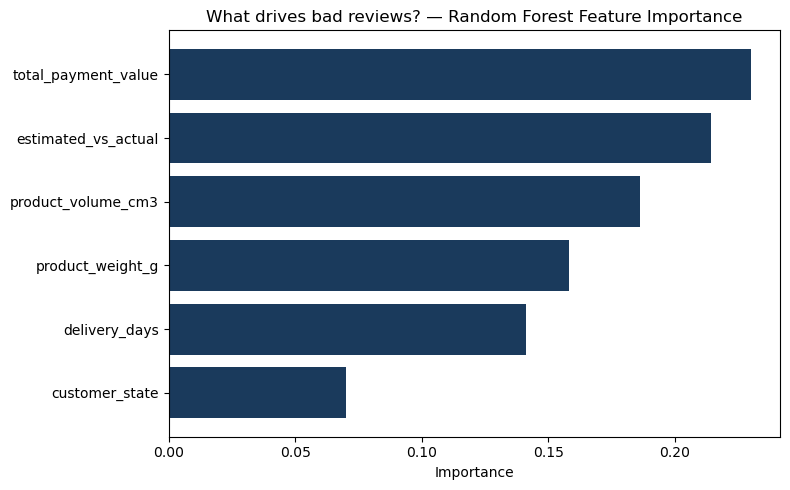

Chart saved.


In [38]:
import matplotlib.pyplot as plt
import numpy as np

# --- Confusion Matrix for Random Forest ---
cm = confusion_matrix(y_test, rf_preds)
print("Confusion Matrix (Random Forest):")
print(f"True Negatives (correctly predicted good): {cm[0][0]}")
print(f"False Positives (predicted bad, actually good): {cm[0][1]}")
print(f"False Negatives (predicted good, actually bad): {cm[1][0]}")
print(f"True Positives (correctly predicted bad): {cm[1][1]}")

# --- Feature Importance ---
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(feature_importance)

# Plot feature importance
plt.figure(figsize=(8, 5))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='#1a3a5c')
plt.xlabel('Importance')
plt.title('What drives bad reviews? — Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("Chart saved.")

In [39]:
# Final model summary
print("=" * 50)
print("MODEL SUMMARY")
print("=" * 50)
print(f"\nObjective: Predict bad reviews (1-3 stars) before they happen")
print(f"\nBaseline — Logistic Regression:")
print(f"  Accuracy: {accuracy_score(y_test, lr_preds):.1%}")
print(f"  F1 Score: {f1_score(y_test, lr_preds):.2f}")
print(f"\nAdvanced — Random Forest:")
print(f"  Accuracy: {accuracy_score(y_test, rf_preds):.1%}")
print(f"  F1 Score: {f1_score(y_test, rf_preds):.2f}")
print(f"\nKey insight: Delivery expectation gap (estimated_vs_actual)")
print(f"is the #2 driver of bad reviews — more important than")
print(f"absolute delivery speed. Olist should focus on accurate")
print(f"delivery promises, not just faster shipping.")
print(f"\nBusiness application: Flag orders with high payment value")
print(f"+ late vs estimate as high risk. Proactively contact")
print(f"these customers before they leave a bad review.")

MODEL SUMMARY

Objective: Predict bad reviews (1-3 stars) before they happen

Baseline — Logistic Regression:
  Accuracy: 79.1%
  F1 Score: 0.25

Advanced — Random Forest:
  Accuracy: 84.1%
  F1 Score: 0.54

Key insight: Delivery expectation gap (estimated_vs_actual)
is the #2 driver of bad reviews — more important than
absolute delivery speed. Olist should focus on accurate
delivery promises, not just faster shipping.

Business application: Flag orders with high payment value
+ late vs estimate as high risk. Proactively contact
these customers before they leave a bad review.
